# Step 4 — Filmweb Prompt, 8 artykułów, 4 modele

Finalne porównanie 4 wybranych modeli na rozszerzonym zbiorze 8 artykułów (prompt `filmweb_pl/new_graph`).

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

df = pd.read_csv("step_4_filmweb_8_articles.csv")
df.columns = [c.strip().lower().replace("-", "_") for c in df.columns]

def short_label(m):
    if m.startswith("local:"):
        m = m[len("local:"):]
    if "/" in m:
        m = m.rsplit("/", 1)[-1]
    return m

df["model_short"] = df["model"].apply(short_label)
df["title_short"] = df["title"].str.replace("_", " ")

# T-F1 — nie ma go bezpośrednio w CSV
df["t_f1"] = 2 * df["t_precision"] * df["t_recall"] / (df["t_precision"] + df["t_recall"])
df["f1"] = 2 * df["precision"] * df["recall"] / (df["precision"] + df["recall"])

TOP4 = ["gemma-4-26b-a4b-it", "gemma-4-31b-it", "mistral-small-3.2-24b-instruct", "qwen3-32b"]
MODEL_COLORS = {
    "gemma-4-26b-a4b-it":             "#e41a1c",
    "gemma-4-31b-it":                 "#377eb8",
    "mistral-small-3.2-24b-instruct": "#4daf4a",
    "qwen3-32b":                      "#984ea3",
}
MODEL_ROW_COLORS = {
    "gemma-4-26b-a4b-it":             "#fff0f0",
    "gemma-4-31b-it":                 "#f0f5ff",
    "mistral-small-3.2-24b-instruct": "#f0fff0",
    "qwen3-32b":                      "#f8f0ff",
}

def color_model(row):
    key = row.get("Model", row.get("model_short", ""))
    color = MODEL_ROW_COLORS.get(key, "")
    return [f"background-color: {color}" for _ in row]

NUMERIC = ["precision", "recall", "f1", "t_precision", "t_recall", "t_f1", "connectivity"]

print(f"{len(df)} rows | {df['model_short'].nunique()} models | {df['title'].nunique()} articles")
display(df[["model_short", "title_short", "precision", "recall", "t_precision", "t_recall", "t_f1"]].head(8))

32 rows | 4 models | 8 articles


,model_short,title_short,precision,recall,t_precision,t_recall,t_f1
0,gemma-4-26b-a4b-it,Langer serial SkyShowtime,1.0,0.784,1.000,0.829,0.906506
1,gemma-4-26b-a4b-it,Maj w Prime Video. Jakie nowości zobaczymy w s...,1.0,0.683,0.821,0.657,0.729901
2,gemma-4-26b-a4b-it,Największe kino plenerowe w Polsce powraca!,1.0,0.667,0.714,0.769,0.740480
3,gemma-4-26b-a4b-it,Porzadny czlowiek - recenzujemy produkcje plat...,1.0,0.500,1.000,0.667,0.800240
4,gemma-4-26b-a4b-it,Siedem nowych filmów w programie 22. MDAG online!,1.0,0.647,1.000,0.550,0.709677
5,gemma-4-26b-a4b-it,The Pitt - Nowy klasyk serialu medycznego. Rec...,1.0,0.667,1.000,1.000,1.000000
6,gemma-4-26b-a4b-it,The Last of Us odcinek 5 tworcy o szokujacych ...,0.8,0.615,0.900,0.750,0.818182
7,gemma-4-26b-a4b-it,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,1.0,0.820,0.951,0.886,0.917350


## Pełna tabela wyników — per artykuł (posortowana po Precision)

In [4]:
display_cols = ["model_short", "precision", "recall", "f1", "hall", "miss",
                "t_precision", "t_recall", "t_f1", "t_hall", "t_miss", "connectivity"]

rename_map = {
    "model_short": "Model",
    "precision": "Prec.", "recall": "Recall", "f1": "F1",
    "hall": "Hall.", "miss": "Miss.",
    "t_precision": "T-Prec.", "t_recall": "T-Recall", "t_f1": "T-F1",
    "t_hall": "T-Hall.", "t_miss": "T-Miss.",
    "connectivity": "Connect.",
}

for article, group in df.groupby("title_short"):
    display(HTML(f"<h3>{article}</h3>"))
    styled = (
        group[display_cols]
        .sort_values("precision", ascending=False)
        .rename(columns=rename_map)
        .style
        .apply(color_model, axis=1)
        .background_gradient(subset=["Prec.", "Recall", "F1", "T-Prec.", "T-Recall", "T-F1"], cmap="RdYlGn", vmin=0, vmax=1)
        .background_gradient(subset=["Connect."], cmap="Blues", vmin=0, vmax=1)
        .format({
            "Prec.": "{:.1%}", "Recall": "{:.1%}", "F1": "{:.1%}",
            "T-Prec.": "{:.1%}", "T-Recall": "{:.1%}", "T-F1": "{:.1%}",
            "Connect.": "{:.3f}",
        })
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap")]}])
        .hide(axis="index")
    )
    display(styled)

Model,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.,Connect.
gemma-4-26b-a4b-it,100.0%,78.4%,87.9%,0 | 29,8 | 37,100.0%,82.9%,90.7%,nan,nan,0.647
gemma-4-31b-it,100.0%,89.5%,94.5%,0 | 17,2 | 19,100.0%,48.6%,65.4%,nan,nan,0.895
mistral-small-3.2-24b-instruct,100.0%,85.2%,92.0%,0 | 23,4 | 27,78.3%,51.4%,62.1%,nan,nan,1.000
qwen3-32b,100.0%,90.0%,94.7%,0 | 18,2 | 20,94.4%,48.6%,64.2%,nan,nan,1.000


Model,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.,Connect.
gemma-4-26b-a4b-it,100.0%,68.3%,81.2%,0 | 28,13 | 41,82.1%,65.7%,73.0%,nan,nan,0.184
mistral-small-3.2-24b-instruct,100.0%,68.3%,81.2%,0 | 28,13 | 41,85.7%,68.6%,76.2%,nan,nan,0.184
qwen3-32b,97.0%,82.1%,88.9%,1 | 33,7 | 39,97.0%,91.4%,94.1%,nan,nan,0.595
gemma-4-31b-it,95.1%,88.6%,91.7%,2 | 41,5 | 44,85.4%,100.0%,92.1%,nan,nan,1.000


Model,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.,Connect.
gemma-4-26b-a4b-it,100.0%,66.7%,80.0%,0 | 14,7 | 21,71.4%,76.9%,74.0%,nan,nan,0.421
gemma-4-31b-it,100.0%,73.3%,84.6%,0 | 11,4 | 15,100.0%,84.6%,91.7%,0 | 11,2 | 13,0.500
qwen3-32b,100.0%,79.4%,88.5%,0 | 27,7 | 34,29.6%,61.5%,40.0%,nan,nan,1.000
mistral-small-3.2-24b-instruct,64.7%,84.6%,73.3%,18 | 51,6 | 39,23.5%,92.3%,37.5%,nan,nan,1.000


Model,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.,Connect.
gemma-4-26b-a4b-it,100.0%,50.0%,66.7%,0 | 2,2 | 4,100.0%,66.7%,80.0%,nan,nan,1.000
gemma-4-31b-it,100.0%,40.0%,57.1%,0 | 2,3 | 5,100.0%,66.7%,80.0%,nan,nan,1.000
qwen3-32b,100.0%,60.0%,75.0%,0 | 3,2 | 5,100.0%,100.0%,100.0%,nan,nan,1.000
mistral-small-3.2-24b-instruct,80.0%,57.1%,66.6%,1 | 5,3 | 7,60.0%,100.0%,75.0%,nan,nan,1.000


Model,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.,Connect.
gemma-4-26b-a4b-it,100.0%,64.7%,78.6%,0 | 11,6 | 17,100.0%,55.0%,71.0%,nan,nan,0.615
gemma-4-31b-it,100.0%,68.4%,81.2%,0 | 13,6 | 19,100.0%,65.0%,78.8%,nan,nan,1.000
mistral-small-3.2-24b-instruct,93.8%,88.2%,90.9%,2 | 32,4 | 34,53.1%,85.0%,65.4%,nan,nan,1.000
qwen3-32b,63.6%,66.7%,65.1%,8 | 22,7 | 21,36.4%,40.0%,38.1%,nan,nan,1.000


Model,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.,Connect.
qwen3-32b,90.9%,71.4%,80.0%,1 | 11,4 | 14,81.8%,75.0%,78.3%,nan,nan,0.692
mistral-small-3.2-24b-instruct,84.6%,73.3%,78.5%,2 | 13,4 | 15,92.3%,100.0%,96.0%,nan,nan,0.643
gemma-4-26b-a4b-it,80.0%,61.5%,69.5%,2 | 10,5 | 13,90.0%,75.0%,81.8%,nan,nan,0.692
gemma-4-31b-it,77.8%,58.3%,66.7%,2 | 9,5 | 12,88.9%,66.7%,76.2%,nan,nan,0.667


Model,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.,Connect.
gemma-4-26b-a4b-it,100.0%,66.7%,80.0%,0 | 6,3 | 9,100.0%,100.0%,100.0%,nan,nan,1.000
gemma-4-31b-it,100.0%,66.7%,80.0%,0 | 6,3 | 9,100.0%,100.0%,100.0%,nan,nan,0.714
qwen3-32b,100.0%,57.1%,72.7%,0 | 4,3 | 7,100.0%,66.7%,80.0%,nan,nan,1.000
mistral-small-3.2-24b-instruct,88.9%,72.7%,80.0%,1 | 9,3 | 11,66.7%,100.0%,80.0%,nan,nan,1.000


Model,Prec.,Recall,F1,Hall.,Miss.,T-Prec.,T-Recall,T-F1,T-Hall.,T-Miss.,Connect.
gemma-4-26b-a4b-it,100.0%,82.0%,90.1%,0 | 41,9 | 50,95.1%,88.6%,91.7%,nan,nan,0.953
gemma-4-31b-it,100.0%,74.4%,85.3%,0 | 29,10 | 39,100.0%,65.9%,79.4%,nan,nan,1.000
mistral-small-3.2-24b-instruct,95.1%,83.0%,88.6%,2 | 41,8 | 47,82.9%,77.3%,80.0%,nan,nan,0.952
qwen3-32b,90.0%,57.4%,70.1%,3 | 30,20 | 47,76.7%,52.3%,62.2%,nan,nan,0.889


## Średnie per model — ranking wg Precision i T-Precision

In [6]:
for sort_col, sort_label in [("precision", "Precision"), ("t_precision", "T-Precision"), ("t_f1", "T-F1")]:
    display(HTML(f"<h4>Ranking wg {sort_label}</h4>"))
    summary = (
        df.groupby("model_short")[NUMERIC]
        .mean()
        .sort_values(sort_col, ascending=False)
        .round(3)
    )
    display(
        summary.style
        .background_gradient(subset=NUMERIC, cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.1%}")
    )

# zachowujemy posortowane po t_f1 do wykresów
summary = (
    df.groupby("model_short")[NUMERIC]
    .mean()
    .sort_values("t_f1", ascending=False)
    .round(3)
)
model_order = summary.index.tolist()

,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
model_short,,,,,,,
gemma-4-26b-a4b-it,97.5%,67.3%,79.2%,92.3%,76.4%,82.8%,68.9%
gemma-4-31b-it,96.6%,69.9%,80.1%,96.8%,74.7%,83.0%,84.7%
qwen3-32b,92.7%,70.5%,79.4%,77.0%,66.9%,69.6%,89.7%
mistral-small-3.2-24b-instruct,88.4%,76.6%,81.4%,67.8%,84.3%,71.5%,84.7%


,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
model_short,,,,,,,
gemma-4-31b-it,96.6%,69.9%,80.1%,96.8%,74.7%,83.0%,84.7%
gemma-4-26b-a4b-it,97.5%,67.3%,79.2%,92.3%,76.4%,82.8%,68.9%
qwen3-32b,92.7%,70.5%,79.4%,77.0%,66.9%,69.6%,89.7%
mistral-small-3.2-24b-instruct,88.4%,76.6%,81.4%,67.8%,84.3%,71.5%,84.7%


,precision,recall,f1,t_precision,t_recall,t_f1,connectivity
model_short,,,,,,,
gemma-4-31b-it,96.6%,69.9%,80.1%,96.8%,74.7%,83.0%,84.7%
gemma-4-26b-a4b-it,97.5%,67.3%,79.2%,92.3%,76.4%,82.8%,68.9%
mistral-small-3.2-24b-instruct,88.4%,76.6%,81.4%,67.8%,84.3%,71.5%,84.7%
qwen3-32b,92.7%,70.5%,79.4%,77.0%,66.9%,69.6%,89.7%


## Wykresy liniowe — metryki per artykuł

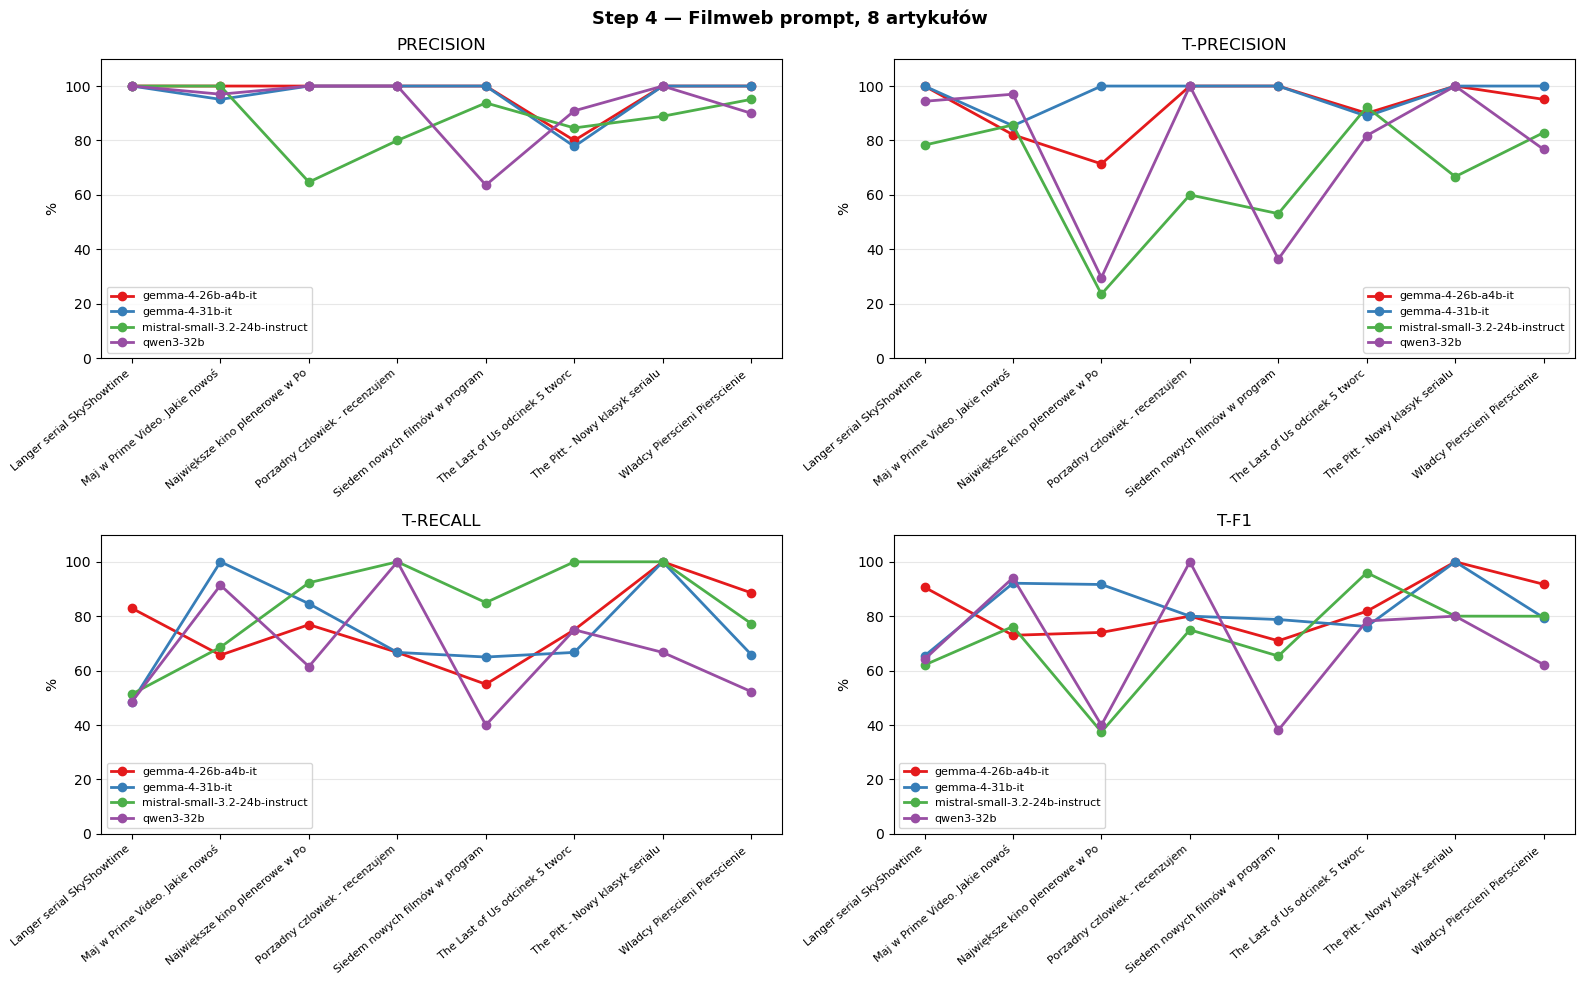

In [8]:
article_order = sorted(df["title_short"].unique())
article_labels = [a[:30] for a in article_order]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, metric in zip(axes, ["precision", "t_precision", "t_recall", "t_f1"]):
    for model in TOP4:
        model_short = short_label(model)
        sub = df[df["model_short"] == model_short].set_index("title_short")
        vals = [sub.loc[a, metric] * 100 if a in sub.index else np.nan for a in article_order]
        ax.plot(range(len(article_order)), vals,
                marker="o", label=model_short, color=MODEL_COLORS[model], linewidth=2)

    ax.set_xticks(range(len(article_order)))
    ax.set_xticklabels(article_labels, rotation=40, ha="right", fontsize=8)
    ax.set_ylim(0, 110)
    ax.set_ylabel("%")
    ax.set_title(metric.replace("_", "-").upper())
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Step 4 — Filmweb prompt, 8 artykułów", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## Wykres słupkowy — T-F1 per model per artykuł

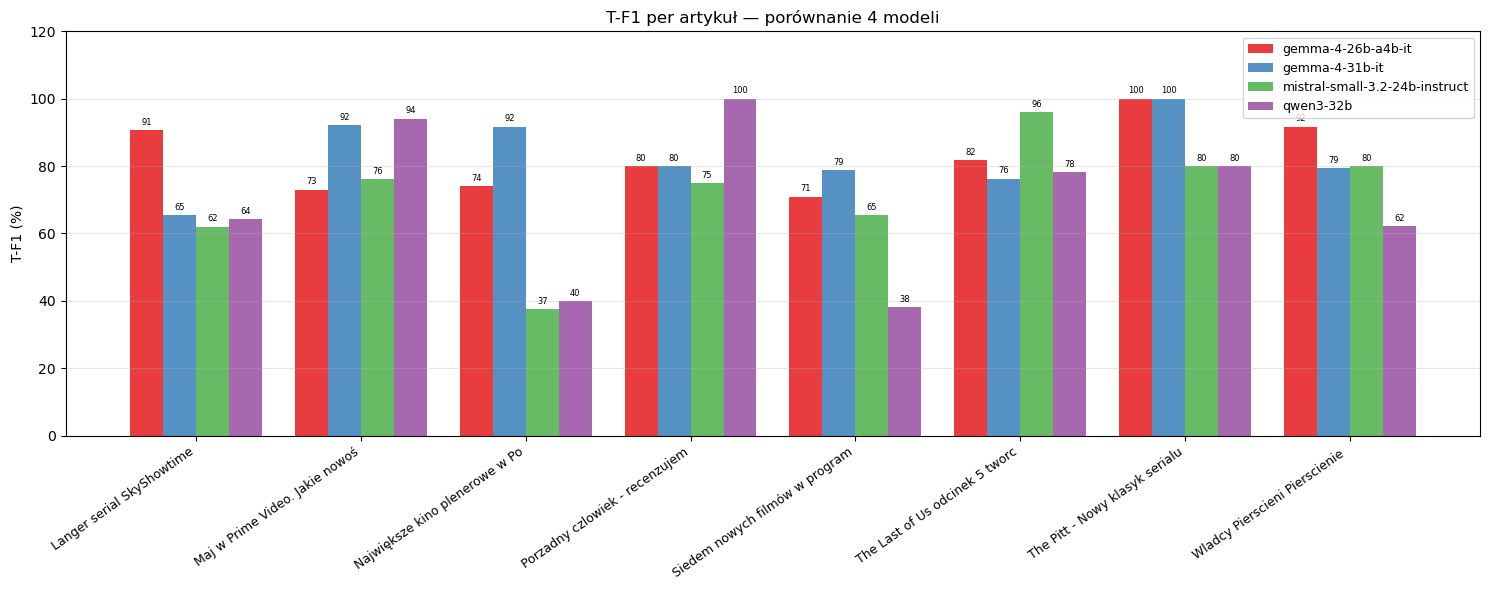

In [10]:
fig, ax = plt.subplots(figsize=(15, 6))

x = np.arange(len(article_order))
w = 0.2
offsets = [-1.5, -0.5, 0.5, 1.5]

for (model, offset) in zip(TOP4, offsets):
    model_short = short_label(model)
    sub = df[df["model_short"] == model_short].set_index("title_short")
    vals = [sub.loc[a, "t_f1"] * 100 if a in sub.index else 0 for a in article_order]
    bars = ax.bar(x + offset * w, vals, w, label=model_short,
                  color=MODEL_COLORS[model], alpha=0.85)
    for bar, v in zip(bars, vals):
        if v > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                    f"{v:.0f}", ha="center", va="bottom", fontsize=6)

ax.set_xticks(x)
ax.set_xticklabels(article_labels, rotation=35, ha="right", fontsize=9)
ax.set_ylim(0, 120)
ax.set_ylabel("T-F1 (%)")
ax.set_title("T-F1 per artykuł — porównanie 4 modeli")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Heatmapa T-F1: model × artykuł

In [12]:
pivot_tf1 = df.pivot_table(index="model_short", columns="title_short", values="t_f1")
pivot_tf1 = pivot_tf1.reindex(model_order)

# dodaj kolumnę ze średnią
pivot_tf1["Średnia"] = pivot_tf1.mean(axis=1)

display(
    pivot_tf1.style
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
    .format("{:.1%}")
    .set_caption("T-F1 per model × artykuł")
    .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap"), ("font-size", "11px")]}])
)

title_short,Langer serial SkyShowtime,Maj w Prime Video. Jakie nowości zobaczymy w serwisie,Największe kino plenerowe w Polsce powraca!,Porzadny czlowiek - recenzujemy produkcje platformy Max,Siedem nowych filmów w programie 22. MDAG online!,The Last of Us odcinek 5 tworcy o szokujacych scenach,The Pitt - Nowy klasyk serialu medycznego. Recenzja,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,Średnia
model_short,,,,,,,,,
gemma-4-31b-it,65.4%,92.1%,91.7%,80.0%,78.8%,76.2%,100.0%,79.4%,83.0%
gemma-4-26b-a4b-it,90.7%,73.0%,74.0%,80.0%,71.0%,81.8%,100.0%,91.7%,82.8%
mistral-small-3.2-24b-instruct,62.1%,76.2%,37.5%,75.0%,65.4%,96.0%,80.0%,80.0%,71.5%
qwen3-32b,64.2%,94.1%,40.0%,100.0%,38.1%,78.3%,80.0%,62.2%,69.6%


## Heatmapa T-Precision i T-Recall

In [14]:
for metric, label in [("t_precision", "T-Precision"), ("t_recall", "T-Recall"), ("precision", "Precision")]:
    pivot = df.pivot_table(index="model_short", columns="title_short", values=metric).reindex(model_order)
    pivot["Średnia"] = pivot.mean(axis=1)
    display(HTML(f"<h4>{label}</h4>"))
    display(
        pivot.style
        .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
        .format("{:.1%}")
        .set_table_styles([{"selector": "th", "props": [("white-space", "nowrap"), ("font-size", "11px")]}])
    )

title_short,Langer serial SkyShowtime,Maj w Prime Video. Jakie nowości zobaczymy w serwisie,Największe kino plenerowe w Polsce powraca!,Porzadny czlowiek - recenzujemy produkcje platformy Max,Siedem nowych filmów w programie 22. MDAG online!,The Last of Us odcinek 5 tworcy o szokujacych scenach,The Pitt - Nowy klasyk serialu medycznego. Recenzja,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,Średnia
model_short,,,,,,,,,
gemma-4-31b-it,100.0%,85.4%,100.0%,100.0%,100.0%,88.9%,100.0%,100.0%,96.8%
gemma-4-26b-a4b-it,100.0%,82.1%,71.4%,100.0%,100.0%,90.0%,100.0%,95.1%,92.3%
mistral-small-3.2-24b-instruct,78.3%,85.7%,23.5%,60.0%,53.1%,92.3%,66.7%,82.9%,67.8%
qwen3-32b,94.4%,97.0%,29.6%,100.0%,36.4%,81.8%,100.0%,76.7%,77.0%


title_short,Langer serial SkyShowtime,Maj w Prime Video. Jakie nowości zobaczymy w serwisie,Największe kino plenerowe w Polsce powraca!,Porzadny czlowiek - recenzujemy produkcje platformy Max,Siedem nowych filmów w programie 22. MDAG online!,The Last of Us odcinek 5 tworcy o szokujacych scenach,The Pitt - Nowy klasyk serialu medycznego. Recenzja,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,Średnia
model_short,,,,,,,,,
gemma-4-31b-it,48.6%,100.0%,84.6%,66.7%,65.0%,66.7%,100.0%,65.9%,74.7%
gemma-4-26b-a4b-it,82.9%,65.7%,76.9%,66.7%,55.0%,75.0%,100.0%,88.6%,76.3%
mistral-small-3.2-24b-instruct,51.4%,68.6%,92.3%,100.0%,85.0%,100.0%,100.0%,77.3%,84.3%
qwen3-32b,48.6%,91.4%,61.5%,100.0%,40.0%,75.0%,66.7%,52.3%,66.9%


title_short,Langer serial SkyShowtime,Maj w Prime Video. Jakie nowości zobaczymy w serwisie,Największe kino plenerowe w Polsce powraca!,Porzadny czlowiek - recenzujemy produkcje platformy Max,Siedem nowych filmów w programie 22. MDAG online!,The Last of Us odcinek 5 tworcy o szokujacych scenach,The Pitt - Nowy klasyk serialu medycznego. Recenzja,Wladcy Pierscieni Pierscienie Wladzy nowi aktorzy,Średnia
model_short,,,,,,,,,
gemma-4-31b-it,100.0%,95.1%,100.0%,100.0%,100.0%,77.8%,100.0%,100.0%,96.6%
gemma-4-26b-a4b-it,100.0%,100.0%,100.0%,100.0%,100.0%,80.0%,100.0%,100.0%,97.5%
mistral-small-3.2-24b-instruct,100.0%,100.0%,64.7%,80.0%,93.8%,84.6%,88.9%,95.1%,88.4%
qwen3-32b,100.0%,97.0%,100.0%,100.0%,63.6%,90.9%,100.0%,90.0%,92.7%


## Scatter: T-Precision vs T-Recall (per artykuł)

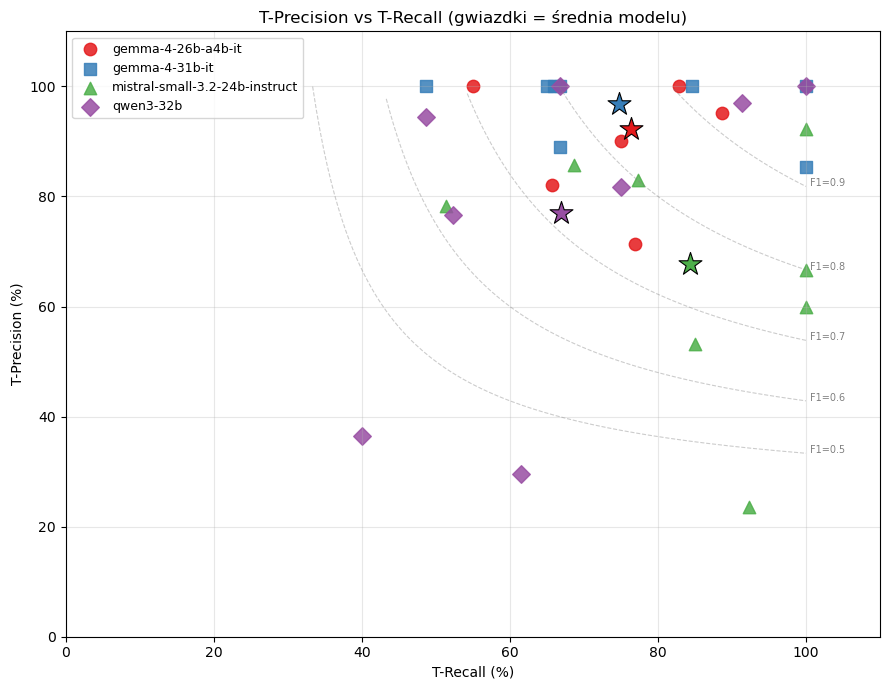

In [16]:
fig, ax = plt.subplots(figsize=(9, 7))

markers = ["o", "s", "^", "D"]
for model, marker in zip(TOP4, markers):
    model_short = short_label(model)
    sub = df[df["model_short"] == model_short]
    ax.scatter(sub["t_recall"] * 100, sub["t_precision"] * 100,
               c=MODEL_COLORS[model], marker=marker, s=80, label=model_short, alpha=0.85)

# srednie
for model in TOP4:
    model_short = short_label(model)
    sub = df[df["model_short"] == model_short]
    ax.scatter(sub["t_recall"].mean() * 100, sub["t_precision"].mean() * 100,
               c=MODEL_COLORS[model], marker="*", s=300, edgecolors="black", linewidths=0.8, zorder=5)

# izolinie F1
for f1 in [0.5, 0.6, 0.7, 0.8, 0.9]:
    r = np.linspace(0.01, 1, 200)
    p = f1 * r / (2 * r - f1)
    mask = (p > 0) & (p <= 1)
    ax.plot(r[mask] * 100, p[mask] * 100, "--", color="gray", alpha=0.4, linewidth=0.8)
    ax.text(r[mask][-1] * 100 + 0.5, p[mask][-1] * 100, f"F1={f1:.1f}", fontsize=7, color="gray")

ax.set_xlim(0, 110)
ax.set_ylim(0, 110)
ax.set_xlabel("T-Recall (%)")
ax.set_ylabel("T-Precision (%)")
ax.set_title("T-Precision vs T-Recall (gwiazdki = średnia modelu)")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Ranking końcowy — porównanie modeli

In [18]:
ranking_cols = ["precision", "recall", "f1", "t_precision", "t_recall", "t_f1", "connectivity"]
ranking = (
    df.groupby("model_short")[ranking_cols]
    .mean()
    .sort_values("t_f1", ascending=False)
    .round(4)
)
ranking["rank_t_f1"] = ranking["t_f1"].rank(ascending=False).astype(int)
ranking["rank_t_prec"] = ranking["t_precision"].rank(ascending=False).astype(int)
ranking["rank_prec"] = ranking["precision"].rank(ascending=False).astype(int)

display(
    ranking.style
    .background_gradient(subset=ranking_cols, cmap="RdYlGn", vmin=0, vmax=1)
    .format({c: "{:.1%}" for c in ranking_cols})
    .set_caption("Ranking końcowy wg T-F1")
)

,precision,recall,f1,t_precision,t_recall,t_f1,connectivity,rank_t_f1,rank_t_prec,rank_prec
model_short,,,,,,,,,,
gemma-4-31b-it,96.6%,69.9%,80.2%,96.8%,74.7%,83.0%,84.7%,1,1,2
gemma-4-26b-a4b-it,97.5%,67.3%,79.2%,92.3%,76.3%,82.8%,68.9%,2,2,1
mistral-small-3.2-24b-instruct,88.4%,76.5%,81.4%,67.8%,84.3%,71.5%,84.7%,3,4,4
qwen3-32b,92.7%,70.5%,79.4%,77.0%,66.9%,69.6%,89.7%,4,3,3


## Wnioski

Wnioski na podstawie 4 modeli × 8 artykułów z promptem filmweb:

**1. gemma-4-31b-it — najwyższe T-F1 (~83%) i T-Precision (~96.8%)**
Ekstraktoruje trafnie i z wysoką pokrytością semantyczną. Najwyższa T-Precision w całym rankingu — prawie żadnych halucynacji semantycznych. Słabość: na artykule *Langer (SkyShowtime)* T-Recall spada do 48.6% — model nie wyciągnął połowy relacji referencyjnych.

**2. gemma-4-26b-a4b-it — praktycznie remis z 31b w T-F1 (~82.8%), najwyższa Precision (97.5%)**
Wyróżnia się najwyższą Precision wśród 4 modeli — prawie zerowe halucynacje strukturalne. T-Precision na poziomie 92.3% — nieco niżej niż 31b, ale nadal doskonały. Paradoks potwierdzony: mniejszy model (26b) osiąga wyniki zbliżone lub lepsze niż 31b. Najlepszy wynik: *The Pitt* — T-F1 = 100%.

**3. mistral-small-3.2-24b-instruct — najwyższy T-Recall (~84.3%), ale niestabilny**
Wyjątkowo wysoki T-Recall oznacza, że model semantycznie pokrywa niemal wszystkie relacje referencyjne. Jednak T-Precision (67.8%) jest niska — generuje dużo relacji, część z nich niepotwierdzonych. Katastrofa na *Kino plenerowe* (T-Precision=23.5%): model wyekstrahował ~51 relacji zamiast ~39 referencyjnych, z masową redundancją semantyczną. Najbardziej niestabilny z czwórki.

**4. qwen3-32b — najsłabsze T-F1 (~69.6%), duże wahania**
Dobre wyniki na *Maj w Prime Video* (T-F1=94.1%) i *Porzadny czlowiek* (T-F1=100%), ale zapaść na *MDAG* (T-F1=38.1%) i *Kino plenerowe* (T-F1=40.0%). T-Precision mocno zróżnicowana (min 0.296 na Kino). Model wrażliwy na typ artykułu — dobrze radzi sobie z prostymi recenzjami, gorzej z listami/zestawieniami.

**Podsumowanie:**
- **Gemma (oba warianty)** to najlepsze modele do ekstrakcji grafów wiedzy na polskich artykułach filmweb — bardzo wysoka Precision i T-Precision, stabilne wyniki na 8 artykułach.
- **Mistral** kompensuje niższą T-Precision wysokim T-Recall — może być wartościowy gdy ważniejsza jest kompletność niż trafność.
- **Qwen3-32b** pomimo największego rozmiaru (32B) wypada najsłabiej — szczególnie niespójny na artykułach z dużą liczbą encji (listy premier, festiwale).
- Rozszerzenie z 3 do 8 artykułów potwierdziło wnioski z etapu 3: **gemma-4-26b-a4b-it jest najbardziej zbalansowanym modelem** pod kątem precyzji i T-F1.